In [ ]:

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pad_excel = Path(r"c:\Users\raymo\Documents\DEAI_portfolio\LineaireClassificatie.opdracht\AmesHousing.xlsx")
df_original = pd.read_excel(pad_excel, sheet_name='AmesHousing')

print("✓ Data ingeladen")
print(f"Dataset shape: {df_original.shape}")
print(f"\nEerste paar rijen:")
print(df_original.head())
print(f"\nKolommen beschikbaar:")
print(df_original.columns.tolist())

✓ Data ingeladen
Dataset shape: (2930, 12)

Eerste paar rijen:
   ID  SalePrice Garage  Overall Qual  Gr Liv Area  Total Bsmt SF  Lot Area  \
0   1     215000    yes             6         1656         1080.0     31770   
1   2     105000    yes             5          896          882.0     11622   
2   3     172000    yes             6         1329         1329.0     14267   
3   4     244000    yes             7         2110         2110.0     11160   
4   5     189900    yes             5         1629          928.0     13830   

   Year Built  Full Bath  Bedroom AbvGr Neighborhood House Style  
0        1960          1              3        NAmes      1Story  
1        1961          1              2        NAmes      1Story  
2        1958          1              3        NAmes      1Story  
3        1968          2              3        NAmes      1Story  
4        1997          2              3      Gilbert      2Story  

Kolommen beschikbaar:
['ID', 'SalePrice', 'Garage', 'Overal

In [ ]:

selected_features = ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
target = 'SalePrice'

df_model = df_original[selected_features + [target]].copy()


df_model = df_model.dropna(subset=['SalePrice'])

print(f"✓ {len(selected_features)} FEATURES GESELECTEERD (top 3)")
print(f"  - Overall Qual (NUMERIEK)")
print(f"  - Gr Liv Area (NUMERIEK)")
print(f"  - Neighborhood (CATEGORISCH)")
print(f"✓ {len(df_model)} samples na het verwijderen van missing SalePrice\n")

# One-hot encode 
df_encoded = pd.get_dummies(df_model, columns=['Neighborhood'], drop_first=True)

print(f"✓ One-hot encoding toegepast op 'Neighborhood'")
print(f"✓ Dataset shape na encoding: {df_encoded.shape}\n")

X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

X = X.fillna(X.median(numeric_only=True))

print(f"✓ Features X shape: {X.shape}")
print(f"✓ Target y shape: {y.shape}")


✓ 3 FEATURES GESELECTEERD (top 3)
  - Overall Qual (NUMERIEK)
  - Gr Liv Area (NUMERIEK)
  - Neighborhood (CATEGORISCH)
✓ 2930 samples na het verwijderen van missing SalePrice

✓ One-hot encoding toegepast op 'Neighborhood'
✓ Dataset shape na encoding: (2930, 30)

✓ Features X shape: (2930, 29)
✓ Target y shape: (2930,)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

print(f"✓ Train-test split toegepast (80-20)")
print(f"  - Train set: {X_train.shape[0]} samples")
print(f"  - Test set: {X_test.shape[0]} samples\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features geschaald met StandardScaler")


✓ Train-test split toegepast (80-20)
  - Train set: 2344 samples
  - Test set: 586 samples

✓ Features geschaald met StandardScaler


In [ ]:

model_initial = LinearRegression()
model_initial.fit(X_train_scaled, y_train)

y_pred_initial = model_initial.predict(X_test_scaled)

mae_initial = mean_absolute_error(y_test, y_pred_initial)
mse_initial = mean_squared_error(y_test, y_pred_initial)
rmse_initial = np.sqrt(mse_initial)
r2_initial = r2_score(y_test, y_pred_initial)

print("=" * 50)
print("INITIEEL LINEARREGRESSION MODEL - RESULTATEN")
print("=" * 50)
print(f"MAE:  ${mae_initial:,.0f}")
print(f"MSE:  ${mse_initial:,.0f}")
print(f"RMSE: ${rmse_initial:,.0f}")
print(f"R² Score: {r2_initial:.4f}")
print("=" * 50)


INITIEEL LINEARREGRESSION MODEL - RESULTATEN
MAE:  $24,737
MSE:  $1,525,093,881
RMSE: $39,052
R² Score: 0.8098


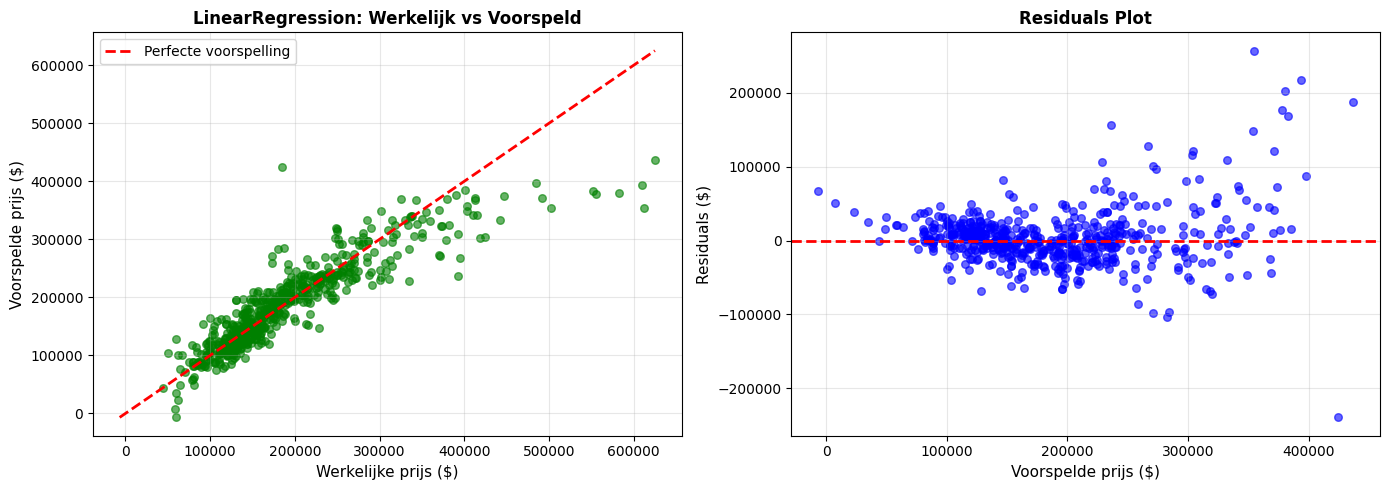

✓ Visualisatie gemaakt


In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_pred_initial, alpha=0.6, color='green', s=30)
min_val = min(y_test.min(), y_pred_initial.min())
max_val = max(y_test.max(), y_pred_initial.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfecte voorspelling')
ax1.set_xlabel('Werkelijke prijs ($)', fontsize=11)
ax1.set_ylabel('Voorspelde prijs ($)', fontsize=11)
ax1.set_title('LinearRegression: Werkelijk vs Voorspeld', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

residuals = y_test - y_pred_initial
ax2.scatter(y_pred_initial, residuals, alpha=0.6, color='blue', s=30)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Voorspelde prijs ($)', fontsize=11)
ax2.set_ylabel('Residuals ($)', fontsize=11)
ax2.set_title('Residuals Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualisatie gemaakt")


In [ ]:

feature_sets = {
    1: ['Overall Qual', 'Gr Liv Area', 'Neighborhood'], 
    2: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built'], 
    3: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath'], 
    4: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area'],  
    5: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area', 'Total Bsmt SF']  
}


hyperparams = [
    {'eta0': 0.001, 'max_iter': 500},
    {'eta0': 0.005, 'max_iter': 1000},
    {'eta0': 0.01, 'max_iter': 2000},
    {'eta0': 0.05, 'max_iter': 5000},
    {'eta0': 0.1, 'max_iter': 10000},
    {'eta0': 0.001, 'max_iter': 5000}
]

print(f"✓ {len(feature_sets)} feature sets gedefinieerd")
print(f"  - Set 1: 3 features (TOP 3 - basis)")
print(f"  - Set 2: 4 features (+Year Built)")
print(f"  - Set 3: 5 features (+Full Bath)")
print(f"  - Set 4: 6 features (+Lot Area)")
print(f"  - Set 5: 7 features (+Total Bsmt SF)")
print(f"\n✓ {len(hyperparams)} hyperparameter combinaties gedefinieerd")
print(f"✓ Totaal experimenten: {len(feature_sets) * len(hyperparams)}")


✓ 5 feature sets gedefinieerd
  - Set 1: 3 features (TOP 3 - basis)
  - Set 2: 4 features (+Year Built)
  - Set 3: 5 features (+Full Bath)
  - Set 4: 6 features (+Lot Area)
  - Set 5: 7 features (+Total Bsmt SF)

✓ 6 hyperparameter combinaties gedefinieerd
✓ Totaal experimenten: 30


In [ ]:

results = []
experiment_id = 1

print("\n" + "="*60)
print("STARTEN MET 30 EXPERIMENTEN")
print("="*60 + "\n")

for fs_id, features in feature_sets.items():
    for hp_id, hp in enumerate(hyperparams, 1):
       
        try:
            df_exp = df_original[features + [target]].copy()
            df_exp = df_exp.dropna(subset=['SalePrice'])
            
            df_exp_encoded = pd.get_dummies(df_exp, columns=['Neighborhood'], drop_first=True)
            
            X_exp = df_exp_encoded.drop('SalePrice', axis=1)
            y_exp = df_exp_encoded['SalePrice']
            X_exp = X_exp.fillna(X_exp.median(numeric_only=True))
            
            
            X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
                X_exp, y_exp, test_size=0.20, random_state=42
            )
            
            
            scaler_exp = StandardScaler()
            X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
            X_test_exp_scaled = scaler_exp.transform(X_test_exp)
            
            
            model_exp = SGDRegressor(
                eta0=hp['eta0'],
                max_iter=hp['max_iter'],
                random_state=42,
                verbose=0
            )
            model_exp.fit(X_train_exp_scaled, y_train_exp)
            
            
            y_pred_exp = model_exp.predict(X_test_exp_scaled)
            mae_exp = mean_absolute_error(y_test_exp, y_pred_exp)
            mse_exp = mean_squared_error(y_test_exp, y_pred_exp)
            rmse_exp = np.sqrt(mse_exp)
            r2_exp = r2_score(y_test_exp, y_pred_exp)
            
            results.append({
                'Exp_ID': experiment_id,
                'Features': len(features),
                'eta0': hp['eta0'],
                'max_iter': hp['max_iter'],
                'MAE': round(mae_exp, 0),
                'MSE': round(mse_exp, 0),
                'RMSE': round(rmse_exp, 0),
                'R2': round(r2_exp, 2)
            })
            
            print(f"Experiment {experiment_id:2d} ✓ | {len(features)} feat | "
                  f"η={hp['eta0']:.3f} | iter={hp['max_iter']:5d} | "
                  f"MAE={mae_exp:8,.0f} | R²={r2_exp:.2f}")
            
        except Exception as e:
            print(f"Experiment {experiment_id:2d} ✗ | Fout: {str(e)}")
        
        experiment_id += 1

print("\n" + "="*60)
print("ALLE EXPERIMENTEN VOLTOOID")
print("="*60)


results_df = pd.DataFrame(results)



STARTEN MET 30 EXPERIMENTEN

Experiment  1 ✓ | 3 feat | η=0.001 | iter=  500 | MAE=  24,735 | R²=0.81
Experiment  2 ✓ | 3 feat | η=0.005 | iter= 1000 | MAE=  24,766 | R²=0.81
Experiment  3 ✓ | 3 feat | η=0.010 | iter= 2000 | MAE=  24,680 | R²=0.81
Experiment  4 ✓ | 3 feat | η=0.050 | iter= 5000 | MAE=81,415,921 | R²=-4277245.92
Experiment  5 ✓ | 3 feat | η=0.100 | iter=10000 | MAE=13,546,993,445 | R²=-3076098461231.10
Experiment  6 ✓ | 3 feat | η=0.001 | iter= 5000 | MAE=  24,735 | R²=0.81
Experiment  7 ✓ | 4 feat | η=0.001 | iter=  500 | MAE=  24,312 | R²=0.81
Experiment  8 ✓ | 4 feat | η=0.005 | iter= 1000 | MAE=  24,354 | R²=0.81
Experiment  9 ✓ | 4 feat | η=0.010 | iter= 2000 | MAE=  24,290 | R²=0.81
Experiment 10 ✓ | 4 feat | η=0.050 | iter= 5000 | MAE=175,251,326 | R²=-11696387.35
Experiment 11 ✓ | 4 feat | η=0.100 | iter=10000 | MAE=12,201,059,477 | R²=-2372633643444.70
Experiment 12 ✓ | 4 feat | η=0.001 | iter= 5000 | MAE=  24,312 | R²=0.81
Experiment 13 ✓ | 5 feat | η=0.001 |